In [1]:
import pandas as pd
import dataframe_image as dfi
import matplotlib.pyplot as plt

df = pd.read_csv("data/cleaned/intake_form.csv")

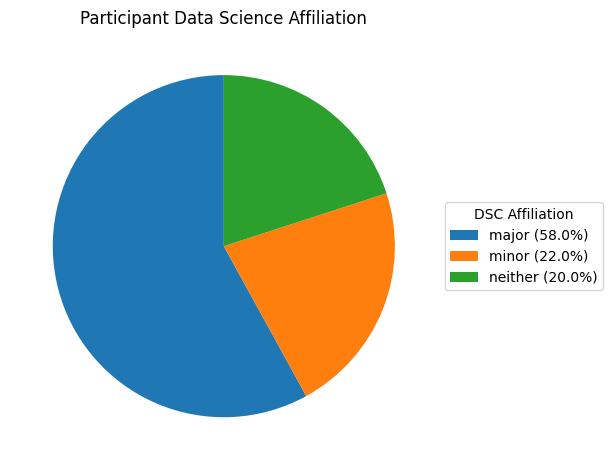

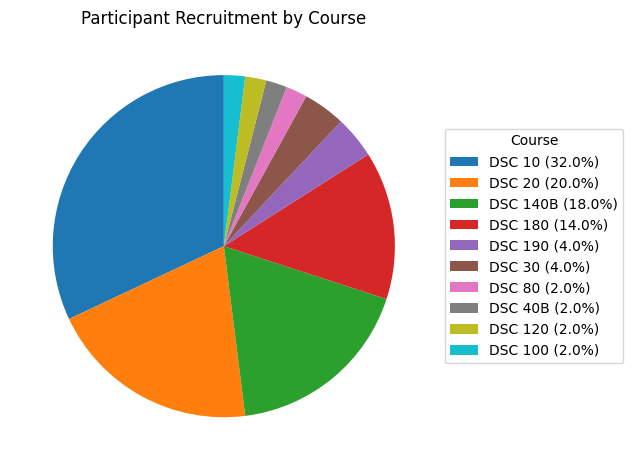

In [2]:
df = pd.read_csv("data/cleaned/intake_form.csv")

#Pie chart: Data Science affiliation
aff_counts = df['dsc_affiliation'].value_counts()
aff_labels = [f"{label} ({count / aff_counts.sum() * 100:.1f}%)" for label, count in zip(aff_counts.index, aff_counts)]

plt.figure()
wedges, _ = plt.pie(
    aff_counts,
    startangle=90
)

plt.title("Participant Data Science Affiliation")

plt.legend(
    wedges,
    aff_labels,
    title="DSC Affiliation",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.savefig("outputs/intake_form_visualization/data_science_affiliation.png", dpi=300, bbox_inches='tight')
plt.show()


#Pie chart: Recruitment course
course_counts = df['recruitment_source'].value_counts()
course_labels = [f"{label} ({count / course_counts.sum() * 100:.1f}%)" for label, count in zip(course_counts.index, course_counts)]

plt.figure()
wedges, _ = plt.pie(
    course_counts,
    startangle=90
)

plt.title("Participant Recruitment by Course")

plt.legend(
    wedges,
    course_labels,
    title="Course",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.savefig("outputs/intake_form_visualization/recruitment_course_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
df2 = pd.read_csv("data/cleaned/status.csv")
completion_rate = df2.groupby('section')['completed'].mean()

result = completion_rate.reset_index()
dictionary = {
    1: "No coding, No handwritten work",
    2: "Coding only",
    3: "Handwritten only",
    4: "Coding and handwritten work"
}
result['section'] = result['section'].map(dictionary)
final_result = result.set_index('section')
final_result = final_result.rename(columns={'completed': 'Completion Rate'})
final_result
dfi.export(final_result, "outputs/intake_form_visualization/completion_rate.png",table_conversion="chrome", dpi = 300)


In [4]:
df
summary = pd.DataFrame({
    "Mean":[df['python_skill_level'].mean(), df['chebyshev_familiarity'].mean(), df['stats_confidence'].mean()],
    "Median":[df['python_skill_level'].median(), df['chebyshev_familiarity'].median(), df['stats_confidence'].median()],

}, index=['Python skill', 'Chebyshev Familiarity', 'Stats Confidence'])
dfi.export(summary, "outputs/intake_form_visualization/stats.png",table_conversion="chrome", dpi = 300)
summary

,Mean,Median
Python skill,3.34,4.0
Chebyshev Familiarity,2.50,2.0
Stats Confidence,3.26,3.0
